---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---

# Jensen's Inequality

## 1\. Convex Functions

::: {#def-convex-function}
## Convex Function
A real-valued function $g: I \to \mathbb{R}$ defined on an interval $I \subseteq \mathbb{R}$ is **convex** if for all $x_1, x_2 \in I$ and for any parameter $\lambda \in [0, 1]$:
$$
g(\lambda x_1 + (1 - \lambda)x_2) \leq \lambda g(x_1) + (1 - \lambda)g(x_2)
$$
If $g$ is twice differentiable on the interval $I$, an **easy method** to verify convexity is checking that its second derivative is non-negative everywhere on $I$:
$$
g''(x) \geq 0 \quad \forall x \in I
$$
:::

## 2\. Statement and Proof of Jensen's Inequality

::: {#thm-jensens-inequality}
## Jensen's Inequality
Let $X$ be a [Random Variable](random-variables.ipynb) such that its [Expectation](expectation.ipynb) $E(X)$ exists, and let $g: \mathbb{R} \to \mathbb{R}$ be a **convex function**. Then:
$$
E[g(X)] \geq g(E[X])
$$
*(If $g$ is strictly convex, equality holds if and only if $X$ is a constant almost surely, i.e., $X = E(X)$ with probability $1$.)*
:::

::: {.callout-tip collapse="true"}
## Proof of Jensen's Inequality (Supporting Hyperplane Method)
Let $\mu = E(X)$. Because $g(x)$ is a convex function, at the point $(\mu, g(\mu))$ there exists a supporting line (or tangent line, when $g$ is differentiable at $\mu$) that lies entirely on or below the graph of $g(x)$ for all $x \in \mathbb{R}$.

Let the equation of this supporting line be given by $y = a + bx$, where the line touches the curve exactly at $x = \mu$, which implies:
$$
g(\mu) = a + b\mu
$$
Because the convex curve lies above or on the supporting tangent line everywhere:
$$
g(x) \geq a + bx \quad \forall x \in \mathbb{R}
$$
Now, evaluate this inequality at the random variable $X$. Since the inequality holds for all real numbers $x$, it holds for every outcome of the random variable $X$:
$$
g(X) \geq a + bX
$$
Taking the [Expectation](expectation.ipynb) of both sides of this random inequality and applying the linearity of expectation:
$$
\begin{aligned}
E[g(X)] &\geq E[a + bX] \\
&= a + b E(X) \\
&= a + b\mu
\end{aligned}
$$
Since $a + b\mu = g(\mu) = g(E[X])$, substituting this back yields directly:
$$
E[g(X)] \geq g(E[X])
$$
$\blacksquare$
:::

## 3\. Simple Example: Second Moment and Non-Negative Variance
We can apply **Jensen's Inequality** to derive a fundamental property of probability distributions.

Consider the quadratic function $g(x) = x^2$. To verify its convexity using the **easy method**, we compute its derivatives:
$$
\begin{aligned}
g'(x) &= 2x \\
g''(x) &= 2 \geq 0
\end{aligned}
$$
Because $g''(x) \geq 0$ for all $x \in \mathbb{R}$, the function $g(x) = x^2$ is strictly convex. 

Applying **Jensen's Inequality** ($E[g(X)] \geq g(E[X])$) directly to $g(x) = x^2$ yields the second moment inequality:
$$
E(X^2) \geq (E[X])^2
$$

::: {.callout-note}
## Intuition: Non-Negativity of Variance
By rearranging the terms of the inequality above, we obtain:
$$
E(X^2) - (E[X])^2 \geq 0
$$
Since the left-hand side is precisely the definition of the [Variance](variance.ipynb) of $X$, this provides an immediate proof that the variance of any random variable is always non-negative:
$$
\text{Var}(X) \geq 0
$$
:::

In [1]:
import warnings
warnings.filterwarnings('ignore')

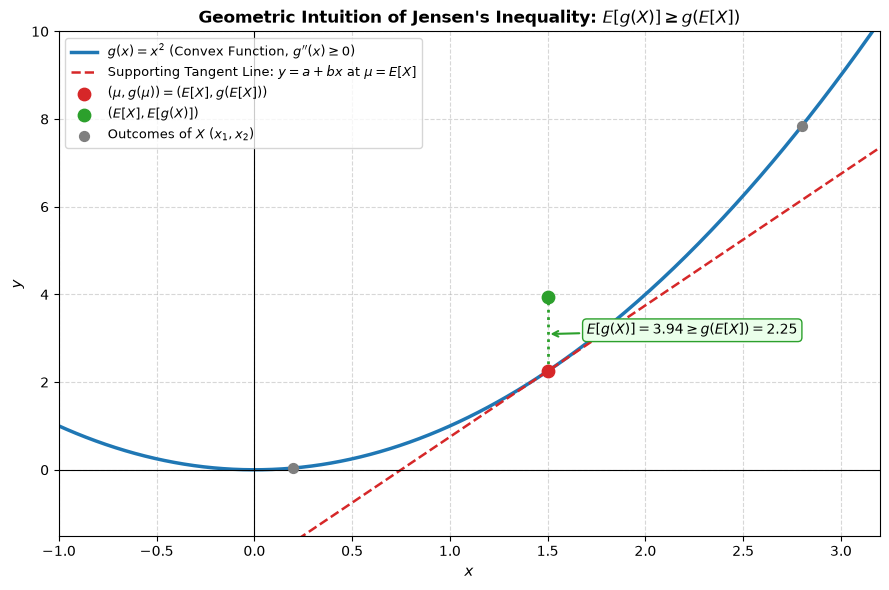

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the convex function g(x) = x^2 and its derivative
def g(x):
    return x**2

def g_prime(x):
    return 2 * x

# Generate x values for plotting
x = np.linspace(-1.5, 3.5, 400)
y = g(x)

# Consider a discrete random variable X taking two values x1 and x2 with equal probability
x1, x2 = 0.2, 2.8
p1, p2 = 0.5, 0.5
mu = p1 * x1 + p2 * x2  # E[X] = 1.5
E_gx = p1 * g(x1) + p2 * g(x2)  # E[g(X)] = 0.5*(0.04) + 0.5*(7.84) = 3.94
g_mu = g(mu)  # g(E[X]) = 1.5^2 = 2.25

# Tangent line at x = mu: y = g(mu) + g'(mu)*(x - mu) = a + bx
tangent_y = g_mu + g_prime(mu) * (x - mu)

# Plotting
plt.figure(figsize=(9, 6))

# Plot convex function and tangent supporting line
plt.plot(x, y, label="$g(x) = x^2$ (Convex Function, $g''(x) \geq 0$)", color="#1f77b4", linewidth=2.5)
plt.plot(x, tangent_y, label="Supporting Tangent Line: $y = a + bx$ at $\mu = E[X]$", color="#d62728", linestyle="--", linewidth=1.8)

# Highlight points of interest
plt.scatter([mu], [g_mu], color="#d62728", s=80, zorder=5, label="$(\mu, g(\mu)) = (E[X], g(E[X]))$")
plt.scatter([mu], [E_gx], color="#2ca02c", s=80, zorder=5, label="$(E[X], E[g(X)])$")
plt.scatter([x1, x2], [g(x1), g(x2)], color="#7f7f7f", s=50, zorder=4, label="Outcomes of $X$ ($x_1, x_2$)")

# Vertical dashed lines showing the inequality difference E[g(X)] >= g(E[X])
plt.plot([mu, mu], [g_mu, E_gx], color="#2ca02c", linestyle=":", linewidth=2)
plt.annotate(f"$E[g(X)] = {E_gx:.2f} \geq g(E[X]) = {g_mu:.2f}$", 
             xy=(mu, (E_gx + g_mu) / 2), xytext=(mu + 0.2, (E_gx + g_mu) / 2),
             arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5),
             fontsize=10, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", facecolor="#eaffea", edgecolor="#2ca02c"))

# Formatting
plt.title("Geometric Intuition of Jensen's Inequality: $E[g(X)] \geq g(E[X])$", fontsize=12, fontweight="bold")
plt.xlabel("$x$", fontsize=11)
plt.ylabel("$y$", fontsize=11)
plt.xlim(-1.0, 3.2)
plt.ylim(-1.5, 10.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(loc="upper left", fontsize=9.5)

plt.tight_layout()
plt.show()